In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)


In [ ]:


df = pd.read_excel("alzheimer_knn_dataset_1000.xlsx")

print("Shape du dataset :", df.shape)
print("\nAperçu des données :")
print(df.head())

print("\nInformations générales :")
print(df.info())

print("\nStatistiques descriptives :")
print(df.describe(include='all'))

Shape du dataset : (1000, 18)

Aperçu des données :
   patient_id  age   sexe antecedents_familiaux hypertension diabete  \
0           1   90  Homme                   Oui          Oui     Non   
1           2   64  Femme                   Non          Non     Oui   
2           3   52  Femme                   Non          Non     Non   
3           4   74  Femme                   Non          Non     Oui   
4           5   90  Homme                   Non          Non     Non   

   niveau_education_annees activite_physique   bmi  heures_sommeil  \
0                        3           Moyenne  28.5             6.6   
1                        5           Moyenne  22.4             6.5   
2                       17            Faible  20.5             5.1   
3                       11            Faible  19.9             6.6   
4                        7            Élevée  28.5             5.8   

   score_depression tabagisme  cholesterol_mg_dl activite_sociale  \
0                 6      

In [ ]:
target_col = "cible_risque_alzheimer"
feature_cols = [col for col in df.columns if col not in [target_col, "patient_id"]]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("\nVariable cible :", target_col)
print("Variables explicatives :")
print(feature_cols)

print("\nRépartition de la cible :")
print(y.value_counts())



Variable cible : cible_risque_alzheimer
Variables explicatives :
['age', 'sexe', 'antecedents_familiaux', 'hypertension', 'diabete', 'niveau_education_annees', 'activite_physique', 'bmi', 'heures_sommeil', 'score_depression', 'tabagisme', 'cholesterol_mg_dl', 'activite_sociale', 'score_memoire', 'score_orientation', 'mmse']

Répartition de la cible :
cible_risque_alzheimer
Non risque    529
Risque        471
Name: count, dtype: int64


In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("\nColonnes numériques :", numerical_cols)
print("Colonnes catégorielles :", categorical_cols)


print("\nValeurs manquantes avant traitement :")
print(df.isnull().sum())


Colonnes numériques : ['age', 'niveau_education_annees', 'bmi', 'heures_sommeil', 'score_depression', 'cholesterol_mg_dl', 'score_memoire', 'score_orientation', 'mmse']
Colonnes catégorielles : ['sexe', 'antecedents_familiaux', 'hypertension', 'diabete', 'activite_physique', 'tabagisme', 'activite_sociale']

Valeurs manquantes avant traitement :
patient_id                 0
age                        0
sexe                       0
antecedents_familiaux      0
hypertension               0
diabete                    0
niveau_education_annees    0
activite_physique          0
bmi                        0
heures_sommeil             0
score_depression           0
tabagisme                  0
cholesterol_mg_dl          0
activite_sociale           0
score_memoire              0
score_orientation          0
mmse                       0
cible_risque_alzheimer     0
dtype: int64


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nClasses de la cible encodée :")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{cls} -> {i}")


Classes de la cible encodée :
Non risque -> 0
Risque -> 1


In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nTaille X_train :", X_train.shape)
print("Taille X_test  :", X_test.shape)


Taille X_train : (800, 16)
Taille X_test  : (200, 16)


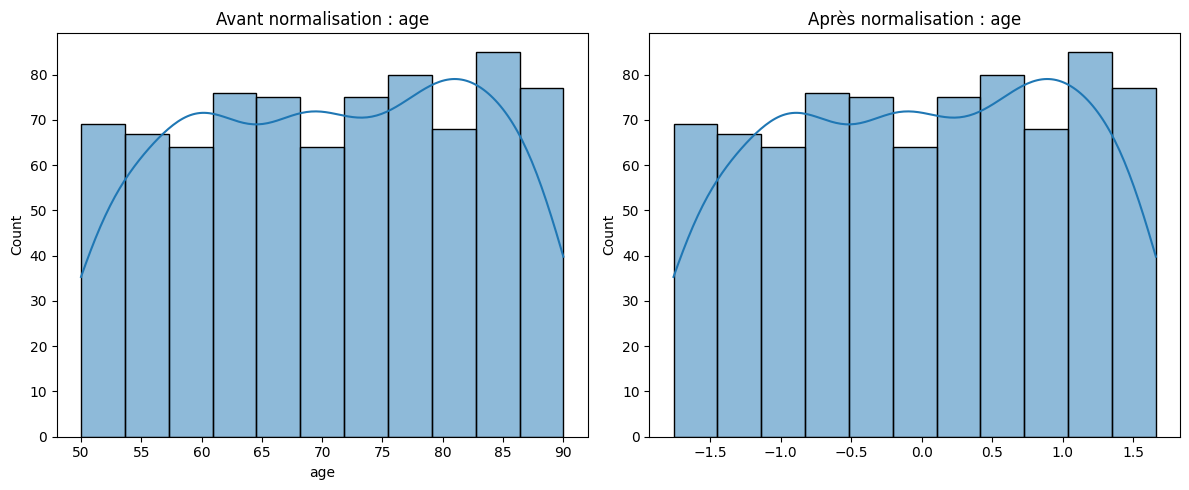

In [ ]:
if len(numerical_cols) > 0:
    col_example = numerical_cols[0]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(X_train[col_example], kde=True)
    plt.title(f"Avant normalisation : {col_example}")

    X_train_num_imputed = X_train[numerical_cols].copy()
    for col in numerical_cols:
        X_train_num_imputed[col] = X_train_num_imputed[col].fillna(X_train_num_imputed[col].median())

    scaler = StandardScaler()
    X_train_scaled_preview = scaler.fit_transform(X_train_num_imputed)

    plt.subplot(1, 2, 2)
    sns.histplot(X_train_scaled_preview[:, numerical_cols.index(col_example)], kde=True)
    plt.title(f"Après normalisation : {col_example}")

    plt.tight_layout()
    plt.show()

In [ ]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = []

best_model_name = None
best_model_pipeline = None
best_f1 = -1

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["classifier"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    if y_proba is not None:
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    results.append({
        "Modèle": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": auc
    })

    if f1 > best_f1:
        best_f1 = f1
        best_model_name = model_name
        best_model_pipeline = pipeline


Tableau comparatif des performances :
          Modèle  Accuracy  Precision    Recall  F1-score   ROC-AUC
0            KNN     0.895   0.974026  0.797872  0.877193  0.965074
1  Decision Tree     0.845   0.853933  0.808511  0.830601  0.842935


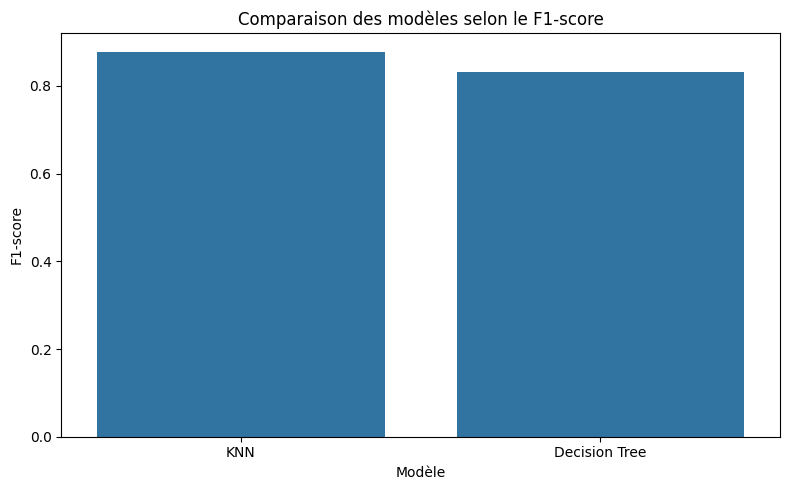

In [ ]:
results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)

print("\nTableau comparatif des performances :")
print(results_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Modèle", y="F1-score")
plt.title("Comparaison des modèles selon le F1-score")
plt.tight_layout()
plt.show()

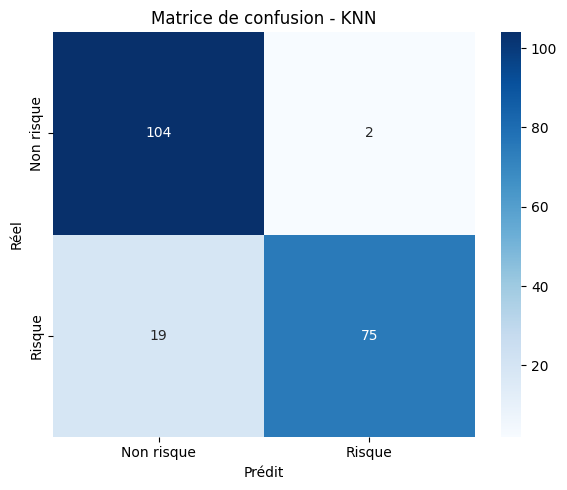

In [ ]:
y_pred_best = best_model_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"Matrice de confusion - {best_model_name}")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

In [ ]:
if hasattr(best_model_pipeline.named_steps["classifier"], "predict_proba"):
    y_proba_best = best_model_pipeline.predict_proba(X_test)[:, 1]
else:
    y_proba_best = None


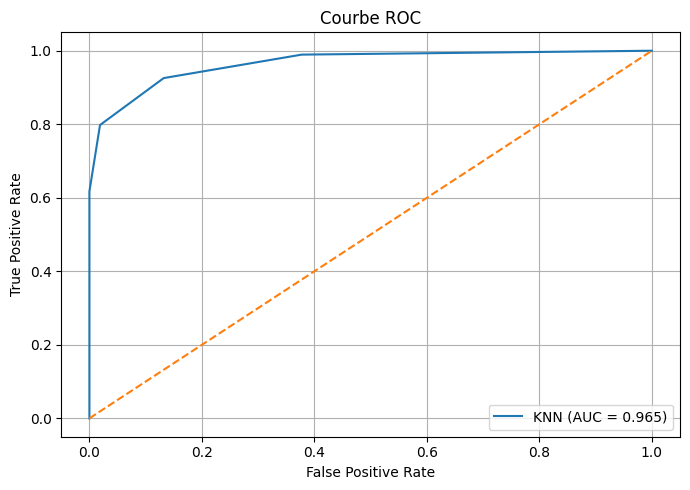

In [ ]:
if y_proba_best is not None:
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
    auc_best = roc_auc_score(y_test, y_proba_best)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {auc_best:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Courbe ROC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Ce modèle ne fournit pas de probabilités pour la courbe ROC.")

In [ ]:
best_row = results_df.iloc[0]

print("\n================ INTERPRÉTATION =================")
print(f"Le meilleur modèle est : {best_row['Modèle']}")
print(f"Accuracy  : {best_row['Accuracy']:.4f}")
print(f"Precision : {best_row['Precision']:.4f}")
print(f"Recall    : {best_row['Recall']:.4f}")
print(f"F1-score  : {best_row['F1-score']:.4f}")
print(f"ROC-AUC   : {best_row['ROC-AUC']:.4f}")

print("\nInterprétation :")
print("- L'accuracy mesure la proportion totale de bonnes prédictions.")
print("- La precision mesure la fiabilité des patients prédits 'à risque'.")
print("- Le recall est très important ici, car il mesure la capacité à détecter les patients réellement à risque.")
print("- Le F1-score donne un équilibre entre precision et recall.")
print("- Le ROC-AUC mesure la capacité globale du modèle à séparer les deux classes.")


================ INTERPRÉTATION =================
Le meilleur modèle est : KNN
Accuracy  : 0.8950
Precision : 0.9740
Recall    : 0.7979
F1-score  : 0.8772
ROC-AUC   : 0.9651

Interprétation :
- L'accuracy mesure la proportion totale de bonnes prédictions.
- La precision mesure la fiabilité des patients prédits 'à risque'.
- Le recall est très important ici, car il mesure la capacité à détecter les patients réellement à risque.
- Le F1-score donne un équilibre entre precision et recall.
- Le ROC-AUC mesure la capacité globale du modèle à séparer les deux classes.


In [ ]:
results_df.to_excel("benchmark_modeles_alzheimer.xlsx", index=False)
results_df.to_excel("benchmark_modeles_alzheimer.xlsx", index=False)

In [ ]:
# Sauvegarde du modèle
import joblib
joblib.dump(pipeline, "model.pkl")

['model.pkl']

In [ ]:
print(X.columns.tolist())

['age', 'sexe', 'antecedents_familiaux', 'hypertension', 'diabete', 'niveau_education_annees', 'activite_physique', 'bmi', 'heures_sommeil', 'score_depression', 'tabagisme', 'cholesterol_mg_dl', 'activite_sociale', 'score_memoire', 'score_orientation', 'mmse']
